# make MarksGroup

In [1]:
%load_ext autoreload
%autoreload 2

import os

os.environ["CUDA_VISIBLE_DEVICES"] = "7"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".99"
import jax
from spyglass.decoding.v1.c3po import (
    Model,
    MarksGroup,
    ModelParams,
    ModelSelection,
)
from spyglass.decoding.v1.clusterless import (
    UnitWaveformFeatures,
    UnitWaveformFeaturesGroup,
)

key = {
    "nwb_file_name": "Wallie20220912_.nwb",
    "waveform_features_group_name": "10_lineartrack",
}

group_query = UnitWaveformFeaturesGroup.UnitFeatures() & key
features_query = UnitWaveformFeatures & group_query
features_keys = features_query.fetch("KEY")

group_name = "10_lineartrack_waveforms"

# MarksGroup().create_group(
#     nwb_file_name="Wallie20220912_.nwb",
#     marks_group_name=group_name,
#     waveforms_keys=features_keys,
#     sorted_spikes_keys=[],
# )

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(
[2026-04-01 15:54:31,180][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306


In [7]:
group_key = {
    "nwb_file_name": "Wallie20220912_.nwb",
    "marks_group_name": group_name,
}
marks, mark_times = MarksGroup().fetch_marks(group_key)

c3po package not found. Please install c3po to use the c3po decoding functionality.


[autoreload of spyglass.decoding.v1.c3po failed: Traceback (most recent call last):
  File "/home/sambray/.local/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/sambray/.local/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/home/sambray/.local/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/sambray/.local/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 349, in update_class
    if update_generic(old_obj, new_obj):
  File "/home/sambray/.local/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/sambray/.local/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 349, in update_class
    if update_generic(old_obj, new_obj):
  File "

Max shank features: 4, number of shanks: 30


In [9]:
marks.shape, mark_times.shape

((747650, 5), (747650,))

# Make ModelParams

In [ ]:
# hyperparams
latent_dim = 3
context_dim = 3

# encoder
encoder_widths = [16, 32, 32]
shank_args = dict(encoder_model="simple", widths=encoder_widths)
encoder_args = dict(
    shank_encoder_params=shank_args,
    encoder_model="multi_shank_v1",
    n_shanks=len(features_keys),
)


# context
dilations = [1, 2, 4, 8, 16]
dilations = dilations * 2
kernels = [10, 20, 64, 64, 128]
kernels = kernels * 2
context_args = dict(
    context_model="wavenet",
    layer_dilations=dilations,
    layer_kernel_size=kernels,
    expanded_dim=64,
    smoothing=10,
    smoothing_decay=0.9,
    categorical=False,
)

rate_args = dict(
    rate_model="bilinear",
)

hazard_model = "poisson"

model_params = dict(
    model_name="wallie_decoding_dim3_v0",
    latent_dim=latent_dim,
    context_dim=context_dim,
    encoder_args=encoder_args,
    context_args=context_args,
    rate_args=rate_args,
    hazard_model=hazard_model,
)

ModelParams().insert1(model_params, skip_duplicates=True)

model_key = {
    "model_name": "wallie_decoding_dim3_v0",
}
ModelParams().get_model(model_key)

C3PO(
    # attributes
    encoder_args = {'shank_encoder_params': {'encoder_model': 'simple', 'widths': [16, 32, 32]}, 'encoder_model': 'multi_shank_v1', 'n_shanks': 30}
    context_args = {'context_model': 'wavenet', 'layer_dilations': [1, 2, 4, 8, 16, 1, 2, 4, 8, 16], 'layer_kernel_size': [10, 20, 64, 64, 128, 10, 20, 64, 64, 128], 'expanded_dim': 64, 'smoothing': 10, 'smoothing_decay': 0.9, 'categorical': False}
    rate_args = {'rate_model': 'bilinear'}
    distribution = 'poisson'
    latent_dim = 3
    context_dim = 3
    n_neg_samples = 1
    predicted_sequence_length = 1
    context_convolutional = None
    sample_params = None
    return_embeddings_in_call = True
)

In [ ]:
(ModelParams()).get_model(model_key)

C3PO(
    # attributes
    encoder_args = {'shank_encoder_params': {'encoder_model': 'simple', 'widths': [16, 32, 64]}, 'encoder_model': 'multi_shank_v1', 'n_shanks': 30}
    context_args = {'context_model': 'wavenet', 'layer_dilations': [1, 2, 4, 8, 16, 1, 2, 4, 8, 16], 'layer_kernel_size': [10, 20, 64, 64, 128, 10, 20, 64, 64, 128], 'expanded_dim': 64, 'smoothing': 1, 'categorical': False}
    rate_args = {'rate_model': 'bilinear'}
    distribution = 'poisson'
    latent_dim = 16
    context_dim = 16
    n_neg_samples = 1
    predicted_sequence_length = 1
    context_convolutional = None
    sample_params = None
    return_embeddings_in_call = False
)

# make TrainingParams

In [5]:
"""
training_params_name: varchar(32)  # name of the training parameters set
---
sample_length: int  # length of each training sample in number of marks
sample_step: int  # step size for sampling training data in number of marks
mark_jitter: float  # amount of jitter to add to mark times to break ties (in seconds)
delta_t_units: enum("s", "ms", "us")  # units to convert delta_t to for training
learning_rate: float  # learning rate for training
n_epochs: int  # (maximum) number of epochs for training
training_function = "c3po_annealing": varchar(32)  # name of the training function to use
training_params: longblob  # additional parameters for the training function
jax_seed = 42: int  # random seed for JAX operations during training
"""

training_params = dict(
    training_params_name="wallie_v0",
    sample_length=5000,
    sample_step=4000,
    mark_jitter=1e-4,
    delta_t_units="ms",
    learning_rate=3e-4,
    n_epochs=1000,
    training_function="c3po_annealing",
    training_params=dict(
        initial_batch_size=64,
        initial_n_neg=8,
        buffer_size=8,
        loss_type="contrastive",
        max_n_neg=256,
        min_batch_size=16,
        multi_gpu=False,
        l1_penalty=None,
    ),
    jax_seed=42,
)
from spyglass.decoding.v1.c3po import TrainingParams

TrainingParams().insert1(training_params, skip_duplicates=True)
# (TrainingParams & {"training_params_name": "wallie_v0"}).delete()
# TrainingParams().delete()

# make Selection

In [6]:
%load_ext autoreload
%autoreload 2
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "8"
import jax
from spyglass.decoding.v1.c3po import (
    Model,
    MarksGroup,
    ModelParams,
    ModelSelection,
)

sel_key = {
    "nwb_file_name": "Wallie20220912_.nwb",
    "training_params_name": "wallie_v0",
    # "model_name": "rat_hpc_lineartrack_v0",
    "model_name": "wallie_decoding_dim3_v0",
    "marks_group_name": "10_lineartrack_waveforms",
    "training_interval_name": "10_lineartrack",
}

ModelSelection().insert1(sel_key, skip_duplicates=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
Model().populate(sel_key)

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

Max shank features: 4, number of shanks: 30
[CudaDevice(id=0)]


Structuring training data: 100%|██████████| 181/181 [00:00<00:00, 216596.01it/s]


x shape (2, 5)
[CudaDevice(id=0)]


Epoch 1:   0%|          | 0/181 [00:00<?, ?samples/s]

...

Stalled training, no further adjustments possible.


  0%|          | 0/725590 [00:00<?, ?it/s]

x shape (1, 5)


 96%|█████████▋| 700000/725590 [00:07<00:00, 92113.66it/s] 
/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines Cam

{'success_count': 1, 'error_list': []}

In [8]:
z_data = (Model() & sel_key).fetch_nwb()[0]["z"]
c_data = (Model() & sel_key).fetch_nwb()[0]["c"]

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  overri

In [9]:
z_data.get_timestamps()

<HDF5 dataset "timestamps": shape (725590,), type "<f8">

In [10]:
import numpy as np

nan_points = np.isnan(z_data.data).any(axis=1)

plt.plot(nan_points)

NameError: name 'plt' is not defined

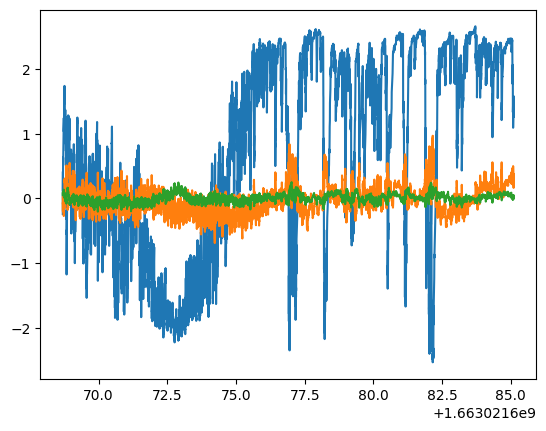

In [15]:
c = c_data.data
import numpy as np
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca.fit(c[~np.isnan(c).any(axis=1)])
c_pca = np.empty_like(c)
c_pca[~np.isnan(c).any(axis=1)] = pca.transform(c[~np.isnan(c).any(axis=1)])

import matplotlib.pyplot as plt

ind = slice(90000, 100000)
plt.plot(c_data.timestamps[ind], c_pca[ind, :10])

In [16]:
sel_key

{'nwb_file_name': 'Wallie20220912_.nwb',
 'training_params_name': 'wallie_v0',
 'model_name': 'wallie_decoding_dim3_v0',
 'marks_group_name': '10_lineartrack_waveforms',
 'training_interval_name': '10_lineartrack'}

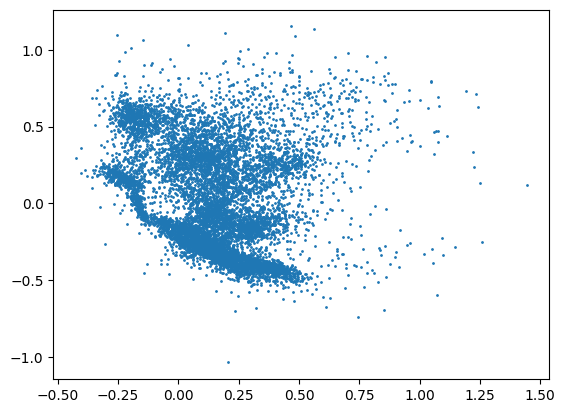

In [ ]:
z = z_data.data[:]
z.shape
ind = np.random.choice(len(z), size=10000, replace=False)
dims = 0, 2
z[ind]
plt.scatter(z[ind, dims[0]], z[ind, dims[1]], s=1)

## Make the Waveform features group

In [31]:
from spyglass.decoding.v1.clusterless import UnitWaveformFeaturesGroup

waveform_features_group_name = "c3po_3dim_10_lineartrack"

UnitWaveformFeaturesGroup().create_group(
    nwb_file_name="Wallie20220912_.nwb",
    group_name=waveform_features_group_name,
    keys=[sel_key],
)

In [2]:
(
    _marks,
    _mark_times,
    _model_params,
    _training_params,
    _training_interval,
) = Model().make_fetch(sel_key)

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

Max shank features: 4, number of shanks: 30


In [3]:
marks = _marks.copy()
mark_times = _mark_times.copy()
model_params = _model_params.copy()
training_params = _training_params.copy()
training_interval = _training_interval.copy()
import numpy as np

### ----------------------------------------------------------


delta_t = np.diff(mark_times)
ind = np.where(delta_t > 0)[0]
delta_t = delta_t[ind]
marks = marks[1:][ind]
if training_params["delta_t_units"] == "ms":
    delta_t *= 1e3
elif training_params["delta_t_units"] == "us":
    delta_t *= 1e6
from spyglass.common.common_interval import Interval
from tqdm import tqdm

sample_length = training_params.pop("sample_length")
sample_step = training_params.pop("sample_step")
training_interval = Interval(training_interval)
valid_inds = np.zeros_like(mark_times, dtype=bool)
valid_inds[training_interval.contains(mark_times, as_indices=True)] = True
x_train = []
delta_t_train = []
i = 0
for i in tqdm(
    range(0, len(marks) - sample_length + 1, sample_step),
    desc="Structuring training data",
):
    if valid_inds[i : i + sample_length].all():
        x_train.append(marks[i : i + sample_length])
        delta_t_train.append(delta_t[i : i + sample_length])
x_train = np.array(x_train)
delta_t_train = np.array(delta_t_train)

Structuring training data: 100%|██████████| 1442/1442 [00:00<00:00, 333619.41it/s]


In [4]:
key = sel_key.copy()
import jax

model = (ModelParams & key).get_model()
rand_key = jax.random.PRNGKey(training_params.pop("jax_seed"))
params = model.init(
    rand_key,
    x_train[:2, :10],
    delta_t_train[:2, :10],
    jax.random.split(rand_key)[0],
)  # initialize model parameters using a small batch of data

x shape (2, 5)


In [5]:
# train the model using the specified training function
from spyglass.decoding.v1.c3po import TRAINING_FUNCTIONS

training_function = TRAINING_FUNCTIONS.get(
    training_params["training_function"], None
)
if training_function is None:
    raise ValueError(
        f"Training function {training_params['training_function']} not found in TRAINING_FUNCTIONS."
    )
params, tracked_loss = training_function(
    model,
    params,
    x_train,
    delta_t_train,
    learning_rate=training_params["learning_rate"],
    n_epochs=training_params["n_epochs"],
    **training_params["training_params"],
)

Epoch 1:   0%|          | 0/1442 [00:00<?, ?samples/s]

x shape (64, 5)


Epoch 1:  22%|██▏       | 320/1442 [00:30<01:48, 10.38samples/s, batch_size=64, loss=71.8, n_neg=2]

Training interrupted by user.


In [2]:
Model().populate(sel_key)

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

Max shank features: 4, number of shanks: 30
[CudaDevice(id=0)]


Structuring training data: 100%|██████████| 1442/1442 [00:00<00:00, 335954.36it/s]


x shape (2, 5)
[CudaDevice(id=0)]


Epoch 1:   0%|          | 0/1442 [00:00<?, ?samples/s]

x shape (64, 5)


Epoch 17:   4%|▍         | 64/1442 [00:01<00:30, 44.75samples/s, batch_size=64, loss=1.19, n_neg=2]


Training interrupted by user.


  0%|          | 0/5 [00:00<?, ?it/s]


ValueError: TimeSeries 'z': Length of data does not match length of timestamps. Your data may be transposed. Time should be on the 0th dimension

In [3]:
%debug

> /home/sambray/.local/lib/python3.10/site-packages/pynwb/core.py(51)_error_on_new_warn_on_construct()
     49         """
     50         if not self._in_construct_mode:
---> 51             raise ValueError(error_msg)
     52         warn(error_msg)
     53 

> /home/sambray/.local/lib/python3.10/site-packages/pynwb/base.py(260)__init__()
    258         error_msg = self._check_time_series_dimension()
    259         if error_msg:
--> 260             self._error_on_new_warn_on_construct(error_msg=error_msg)
    261 
    262     def _check_time_series_dimension(self):

> /home/sambray/.local/lib/python3.10/site-packages/hdmf/utils.py(592)func_call()
    590             def func_call(*args, **kwargs):
    591                 pargs = _check_args(args, kwargs)
--> 592                 return func(args[0], **pargs)
    593         else:
    594             def func_call(*args, **kwargs):

> /home/sambray/Documents/spyglass_dev/spyglass/src/spyglass/decoding/v1/c3po.py(440)make_compute()
   

In [1]:
import jax

jax.devices()

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(


[CudaDevice(id=0),
 CudaDevice(id=1),
 CudaDevice(id=2),
 CudaDevice(id=3),
 CudaDevice(id=4),
 CudaDevice(id=5),
 CudaDevice(id=6),
 CudaDevice(id=7),
 CudaDevice(id=8),
 CudaDevice(id=9)]

In [3]:
%debug

> /home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jax/_src/lax/lax.py(6734)_concatenate_shape_rule()
   6732            "dimension {} for shapes {}.")
   6733     shapes = [operand.shape for operand in operands]
-> 6734     raise TypeError(msg.format(dimension, ", ".join(map(str, shapes))))
   6735 
   6736   concat_size = sum(o.shape[dimension] for o in operands)

> /home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jax/_src/numpy/lax_numpy.py(4625)<listcomp>()
   4623   k = 16
   4624   while len(arrays_out) > 1:
-> 4625     arrays_out = [lax.concatenate(arrays_out[i:i+k], axis)
   4626                   for i in range(0, len(arrays_out), k)]
   4627   return arrays_out[0]

    [... skipped 17 hidden frame(s)]

> /home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jax/_src/numpy/lax_numpy.py(4625)concatenate()
   4623   k = 16
   4624   while len(arrays_out) > 1:
-> 4625     arrays_out = [lax.concat

In [ ]:
import numpy as np

mark_times = np.array([1, 2, 2, 3, 4]).astype(float)

delta_t = np.diff(mark_times)
ind_simultaneous = np.where(delta_t == 0)[0]
np.random.seed(0)  # for reproducibility
mark_times[ind_simultaneous + 1] += np.random.uniform(
    -0.1,
    0.1,
    size=len(ind_simultaneous),
)

In [1]:
ind = np.argsort(mark_times)
mark_times = mark_times[ind]
delta_t = np.diff(mark_times)
print(mark_times)
print(delta_t)

NameError: name 'np' is not defined